## Setup

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%reload_ext autoreload
%autoreload 2


In [86]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

## Import Data

In [9]:
print(sns.get_dataset_names())

['anagrams', 'anscombe', 'attention', 'brain_networks', 'car_crashes', 'diamonds', 'dots', 'dowjones', 'exercise', 'flights', 'fmri', 'geyser', 'glue', 'healthexp', 'iris', 'mpg', 'penguins', 'planets', 'seaice', 'taxis', 'tips', 'titanic']


In [10]:
crash_df = sns.load_dataset('car_crashes')
crash_df.head()

,total,speeding,alcohol,not_distracted,no_previous,ins_premium,ins_losses,abbrev
0,18.8,7.332,5.640,18.048,15.040,784.55,145.08,AL
1,18.1,7.421,4.525,16.290,17.014,1053.48,133.93,AK
2,18.6,6.510,5.208,15.624,17.856,899.47,110.35,AZ
3,22.4,4.032,5.824,21.056,21.280,827.34,142.39,AR
4,12.0,4.200,3.360,10.920,10.680,878.41,165.63,CA


# Distribution Plots

## Distribution Plot

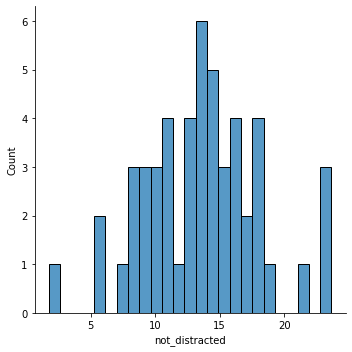

In [13]:
sns.displot(crash_df['not_distracted'], bins = 25)

## Joint Plot

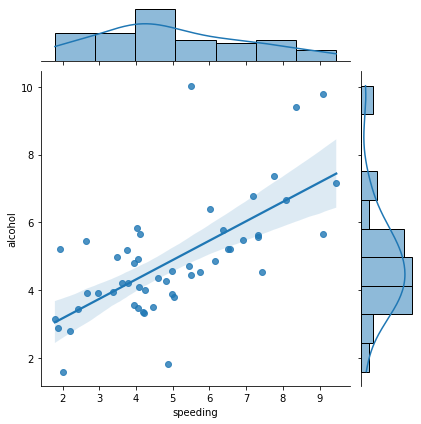

In [17]:
sns.jointplot(x='speeding', y='alcohol', data=crash_df, kind = 'reg')

## KDE Plot

<AxesSubplot: xlabel='alcohol', ylabel='Density'>

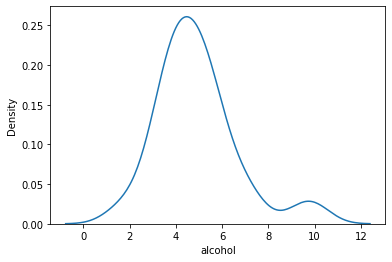

In [18]:
sns.kdeplot(crash_df['alcohol'])

## Pair Plots

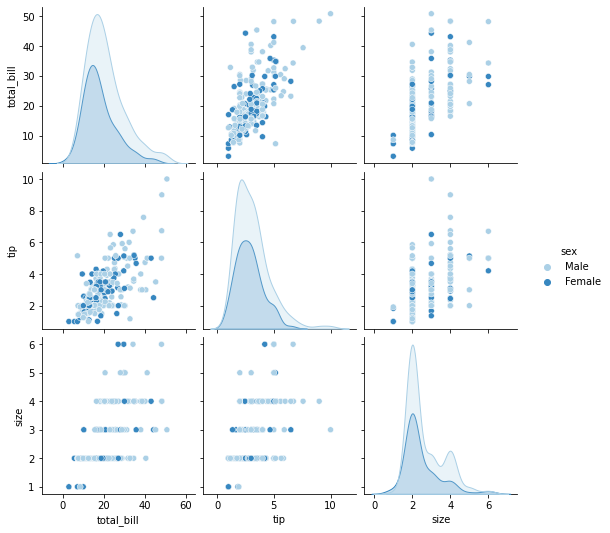

In [22]:
#sns.pairplot(crash_df)
tips_df = sns.load_dataset('tips')
sns.pairplot(tips_df, hue= 'sex' , palette ='Blues')

## Rug Plot

<AxesSubplot: xlabel='tip'>

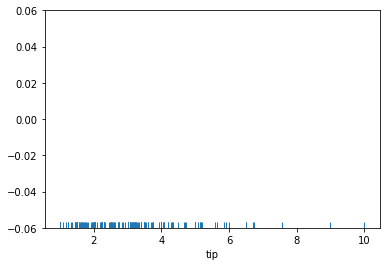

In [23]:
sns.rugplot(tips_df['tip'])

## Styling

<Figure size 576x288 with 0 Axes>

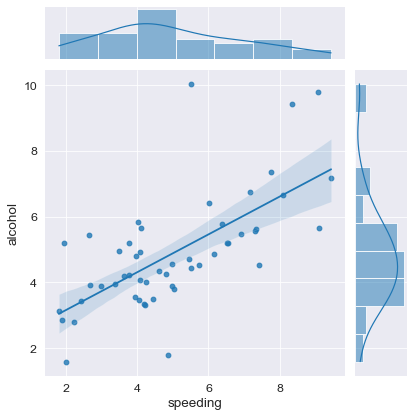

In [30]:
#sns.set_style('white')
#sns.set_style('ticks')
#sns.set_style('dark')

sns.set_style('darkgrid')
plt.figure(figsize = (8,4))
sns.set_context('paper', font_scale=1.4)

sns.jointplot(x='speeding', y='alcohol', data=crash_df, kind = 'reg')
sns.despine(left=True, bottom = True)

# Categorical Plots

## Bar Plots

<AxesSubplot: xlabel='sex', ylabel='total_bill'>

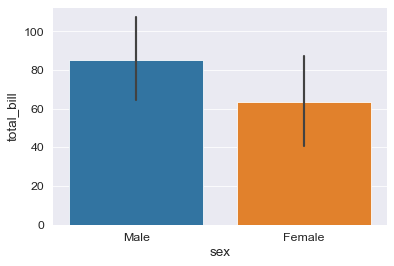

In [35]:
sns.barplot(x='sex', y='total_bill', data = tips_df, estimator=np.var)

## Count Plot

<AxesSubplot: xlabel='sex', ylabel='count'>

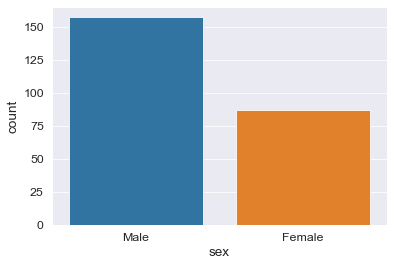

In [36]:
sns.countplot(x='sex', data=tips_df)

## Box Plot

<AxesSubplot: xlabel='day', ylabel='total_bill'>

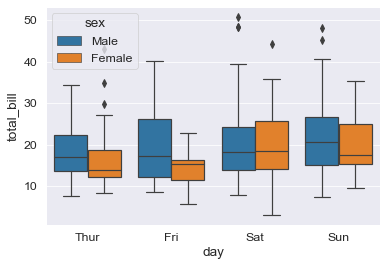

In [41]:
sns.boxplot(x='day', y='total_bill', data=tips_df, hue='sex')


## Violin Plot

<AxesSubplot: xlabel='day', ylabel='total_bill'>

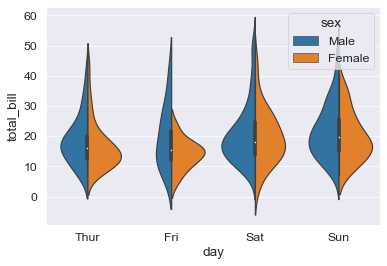

In [42]:
sns.violinplot(x='day', y = 'total_bill', data=tips_df, hue='sex', split=True)

## Strip Plot

<AxesSubplot: xlabel='day', ylabel='total_bill'>

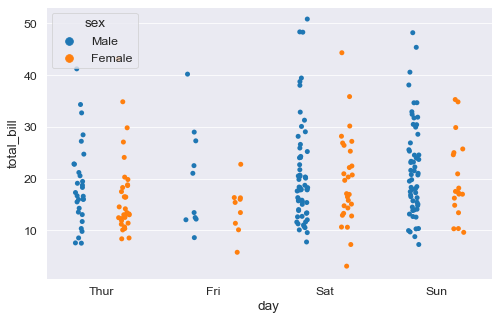

In [45]:
plt.figure(figsize=(8,5))

sns.stripplot(x='day', y='total_bill', data=tips_df, jitter=True, hue='sex', dodge=True)

## Swarm Plot

<AxesSubplot: xlabel='day', ylabel='total_bill'>

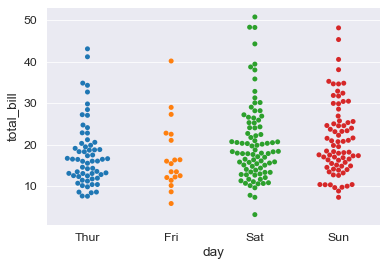

In [46]:
sns.swarmplot(x='day',y='total_bill', data=tips_df)

## Palettes

<AxesSubplot: xlabel='day', ylabel='total_bill'>

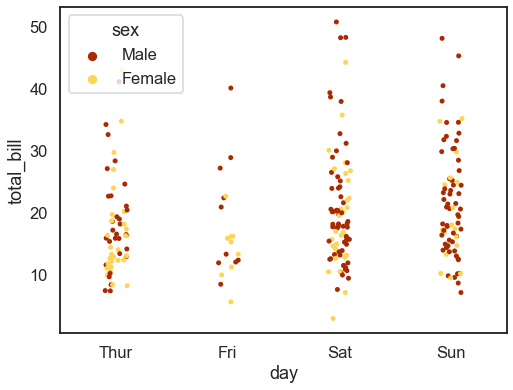

In [53]:
plt.figure(figsize=(8,6))
sns.set_style('white')
sns.set_context('talk')
sns.stripplot(x='day', y='total_bill', data=tips_df, hue='sex', palette='afmhot')


# Matrix Plots

## Heatmap

C:\Users\mprak\AppData\Local\Temp/ipykernel_14900/1506657708.py:4: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  crash_mx=crash_df.corr()


<AxesSubplot: >

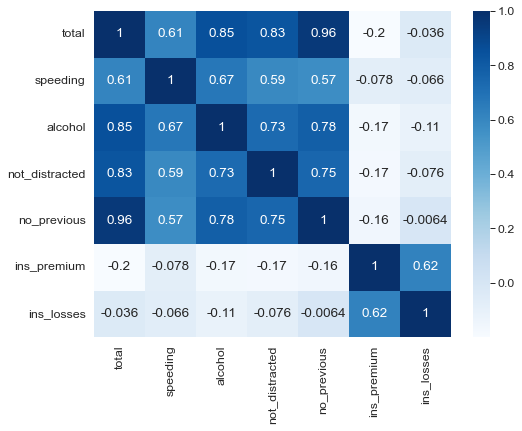

In [56]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)

crash_mx=crash_df.corr()
sns.heatmap(crash_mx, annot=True, cmap='Blues')

In [59]:
flights = sns.load_dataset('flights')
flights = flights.pivot_table(index='month', columns = 'year', values = 'passengers')
flights

year,1949,1950,1951,1952,1953,1954,1955,1956,1957,1958,1959,1960
month,,,,,,,,,,,,
Jan,112,115,145,171,196,204,242,284,315,340,360,417
Feb,118,126,150,180,196,188,233,277,301,318,342,391
Mar,132,141,178,193,236,235,267,317,356,362,406,419
Apr,129,135,163,181,235,227,269,313,348,348,396,461
May,121,125,172,183,229,234,270,318,355,363,420,472
Jun,135,149,178,218,243,264,315,374,422,435,472,535
Jul,148,170,199,230,264,302,364,413,465,491,548,622
Aug,148,170,199,242,272,293,347,405,467,505,559,606
Sep,136,158,184,209,237,259,312,355,404,404,463,508


<AxesSubplot: xlabel='year', ylabel='month'>

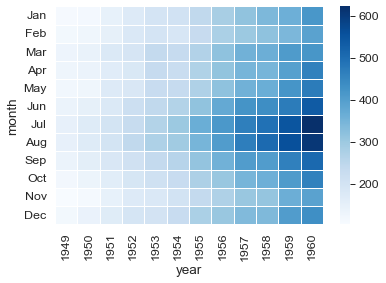

In [60]:
sns.heatmap(flights, cmap='Blues', linecolor = 'white', linewidth =1)

## Cluster Map

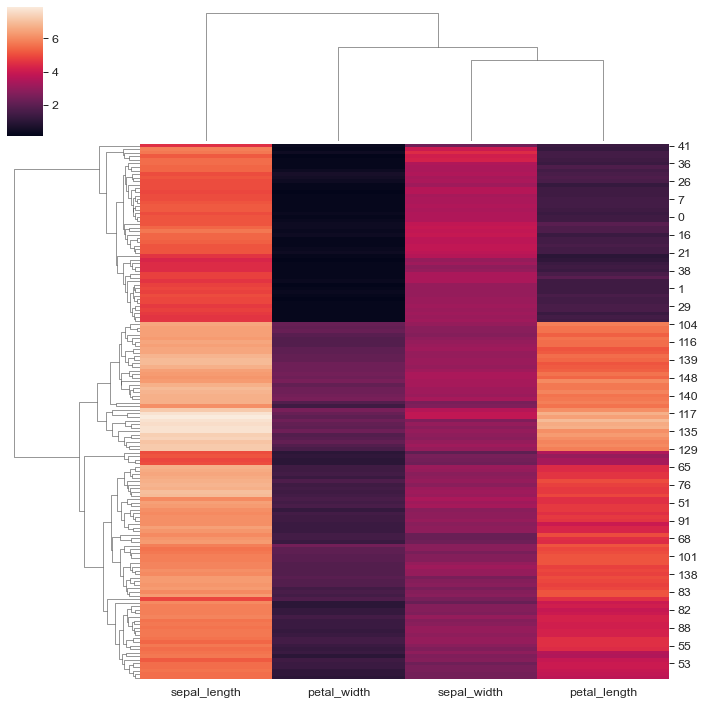

In [65]:
iris = sns.load_dataset('iris')
species = iris.pop('species')
sns.clustermap(iris)

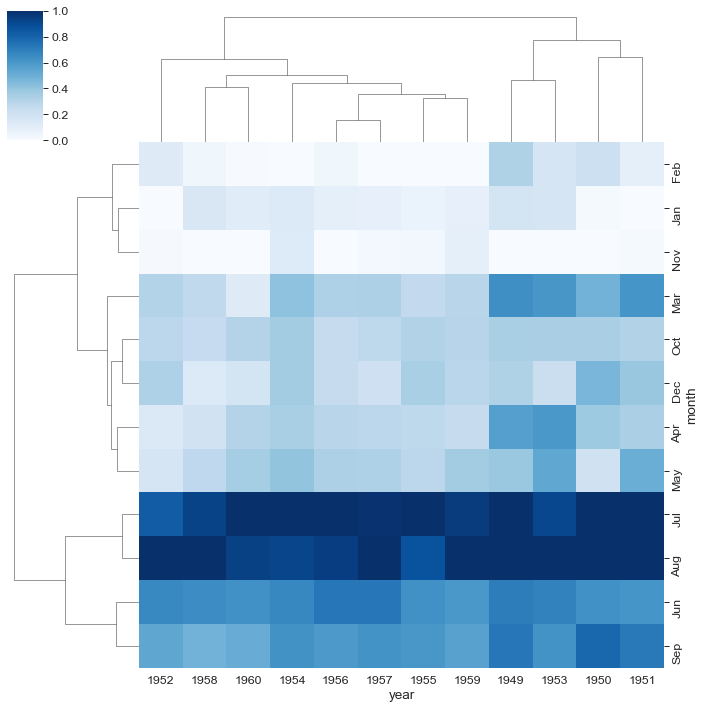

In [66]:
sns.clustermap(flights, cmap='Blues', standard_scale=1)

## Pair Grid

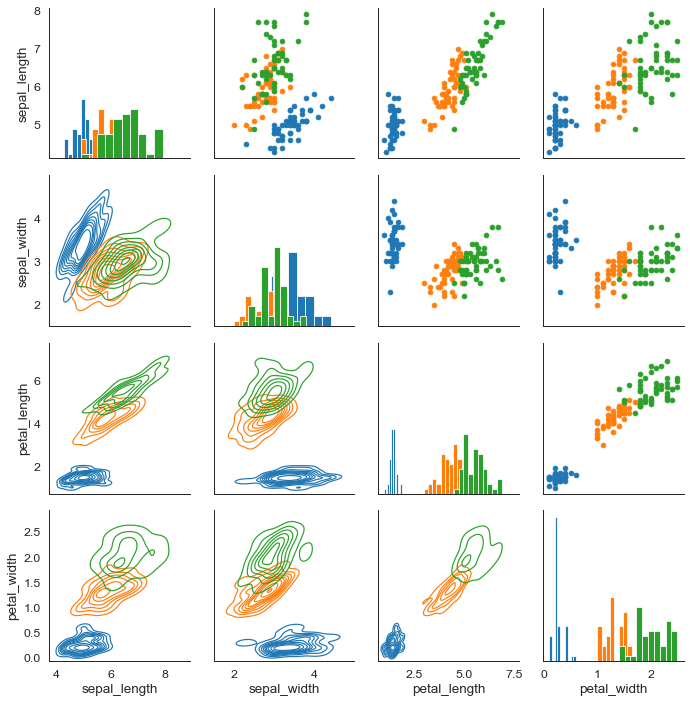

In [72]:
iris = sns.load_dataset('iris')
iris_g = sns.PairGrid(iris, hue='species')
#iris_g.map(plt.scatter)
iris_g.map_diag(plt.hist)
#iris_g.map_offdiag(plt.scatter)
iris_g.map_upper(plt.scatter)
iris_g.map_lower(sns.kdeplot)


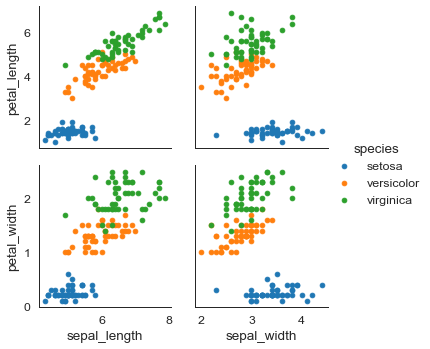

In [74]:
iris_g=sns.PairGrid(iris, hue= 'species', x_vars=['sepal_length', 'sepal_width'], 
                   y_vars=['petal_length', 'petal_width'])
iris_g.map(plt.scatter)
iris_g.add_legend()

# Facet Grid

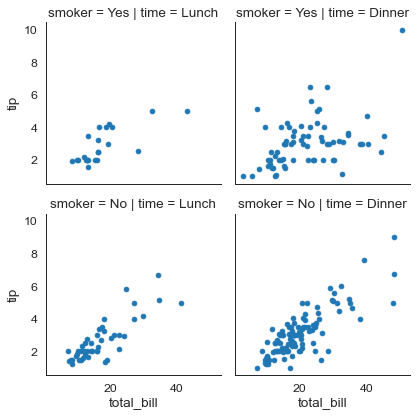

In [85]:
tips_fg = sns.FacetGrid(tips_df, col='time', row='smoker')
tips_fg.map(plt.scatter, 'total_bill', 'tip')

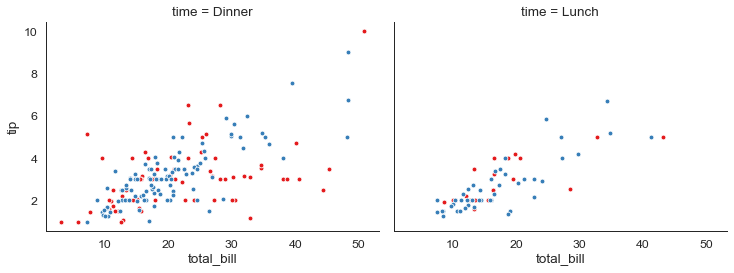

In [84]:
tips_fg = sns.FacetGrid(tips_df, col='time', hue='smoker', height=4, aspect = 1.3, col_order = ['Dinner', 'Lunch'], palette = 'Set1')
tips_fg.map(plt.scatter, 'total_bill', 'tip', edgecolor='w')

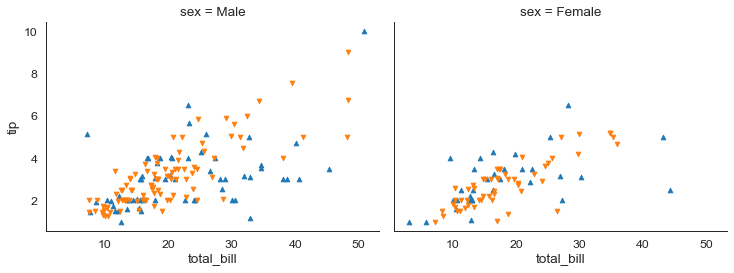

In [83]:
kws = dict(s=50, linewidth=.5, edgecolor='w')
tips_fg=sns.FacetGrid(tips_df, col='sex', hue='smoker', height=4, aspect=1.3, hue_order=['Yes', 'No'], hue_kws=dict(marker=['^','v']))
tips_fg.map(plt.scatter, 'total_bill', 'tip')

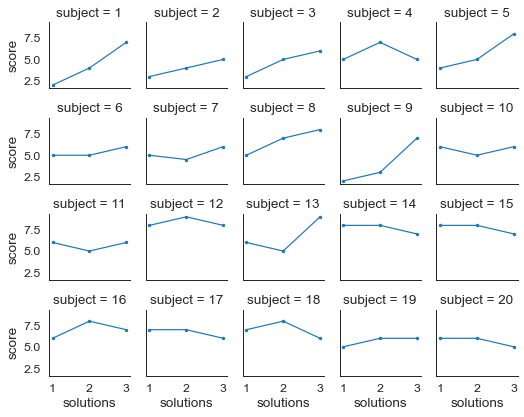

In [82]:
att_df = sns.load_dataset('attention')
att_fg = sns.FacetGrid(att_df, col='subject', col_wrap=5, height=1.5)
att_fg.map(plt.plot, 'solutions', 'score', marker = '.')

# Regression Plots

In [87]:
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


<Figure size 576x432 with 0 Axes>

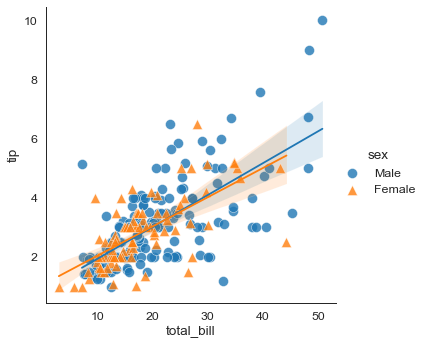

In [88]:
plt.figure(figsize=(8,6))
sns.set_context('paper', font_scale=1.4)
sns.lmplot(x='total_bill', y='tip', hue='sex', data=tips_df, markers=['o', '^'],
          scatter_kws={'s':100, 'linewidth':0.5, 'edgecolor': 'w'})

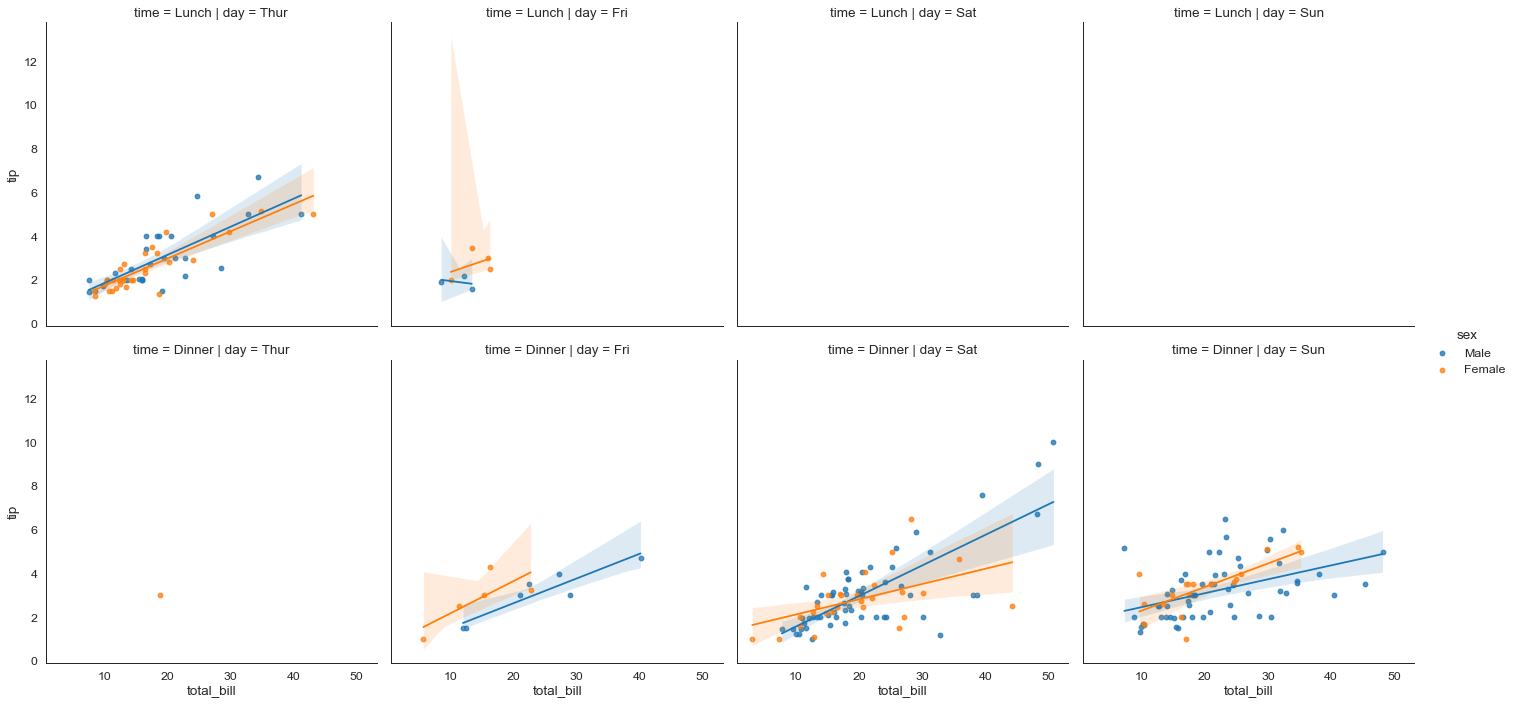

In [90]:
sns.lmplot(x='total_bill', y='tip', col='day', hue='sex', row='time', data=tips_df)